In [60]:
import pandas as pd
import numpy as np
import statsmodels.api as sm


In [61]:
def load_and_prepare(filename):
    """
    Load a stock CSV, clean it, compute log-returns and
    60-day realized volatility (annualized).
    Returns a DataFrame with columns: Date, LogRet, RV
    """

    # ---- 1.1 Read the CSV ----
    df = pd.read_csv(filename)
    print(f"Loaded {filename}, shape = {df.shape}")

    # Some providers use 'Close*' instead of 'Close'
    if "Close*" in df.columns and "Close" not in df.columns:
        df = df.rename(columns={"Close*": "Close"})

    # ---- 1.2 Convert Date to datetime ----
    # If this format fails, remove "format=..." and let pandas guess.
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")

    # ---- 1.3 Clean Close prices (remove commas, convert to float) ----
    df["Close"] = (
        df["Close"]
        .astype(str)                # make sure it's string
        .str.replace(",", "")       # remove thousands commas: "5,881.63" -> "5881.63"
    )
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

    # ---- 1.4 Sort by Date ----
    df = df.sort_values("Date")

    # ---- 1.5 Compute daily log-returns ----
    df["LogRet"] = np.log(df["Close"] / df["Close"].shift(1))

    # ---- 1.6 Compute 60-day rolling realized volatility (annualized) ----
    df["RV"] = df["LogRet"].rolling(window=60).std() * np.sqrt(252)

    # ---- 1.7 Keep only what we need ----
    return df[["Date", "LogRet", "RV"]]

In [62]:
# 2. Load and prepare ALL FOUR FILES
# ============================================================
aapl = load_and_prepare('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/Apple Stock Price History.csv')
nvda = load_and_prepare('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/NVIDIA Stock Price History.csv')
tsla = load_and_prepare('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/Tesla Stock Price History.csv')
spx  = load_and_prepare('/Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/S&P 500 - Historical Data.csv')

# Rename columns so we know which series is which after merging
aapl = aapl.rename(columns={"LogRet": "RET_AAPL", "RV": "RV_AAPL"})
nvda = nvda.rename(columns={"LogRet": "RET_NVDA", "RV": "RV_NVDA"})
tsla = tsla.rename(columns={"LogRet": "RET_TSLA", "RV": "RV_TSLA"})
spx  = spx.rename(columns={"LogRet": "RET_SPX",  "RV": "RV_SPX"})

Loaded /Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/Apple Stock Price History.csv, shape = (3774, 7)
Loaded /Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/NVIDIA Stock Price History.csv, shape = (3774, 7)
Loaded /Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/Tesla Stock Price History.csv, shape = (3651, 7)
Loaded /Users/ambervo/Library/CloudStorage/OneDrive-Personal/Documents/GMBA 3/FinTech/Group Project/data/S&P 500 - Historical Data.csv, shape = (3774, 7)


In [63]:
# ============================================================
# 3. Merge all four on Date into one DataFrame
# ============================================================
data = (
    spx.merge(aapl, on="Date")
       .merge(nvda, on="Date")
       .merge(tsla, on="Date")
)

# Drop rows with NaN from rolling calculations
data = data.dropna().reset_index(drop=True)

print("\nMerged data shape:", data.shape)
print(data.head())


Merged data shape: (3591, 9)
        Date   RET_SPX    RV_SPX  RET_AAPL   RV_AAPL  RET_NVDA   RV_NVDA  \
0 2010-09-24  0.021026  0.185841  0.011561  0.223556  0.066691  0.592495   
1 2010-09-27 -0.005675  0.186193 -0.003839  0.221820 -0.032790  0.596982   
2 2010-09-28  0.004804  0.185805 -0.015504  0.224300  0.000000  0.596982   
3 2010-09-29 -0.002617  0.185893  0.001951  0.224124  0.000000  0.590685   
4 2010-09-30 -0.003062  0.175986 -0.012752  0.212283 -0.033902  0.574910   

   RET_TSLA   RV_TSLA  
0  0.030305  0.750741  
1  0.022141  0.732411  
2  0.042864  0.685378  
3  0.027588  0.574043  
4 -0.077778  0.596875  


In [64]:
# ============================================================
# 4. Benchmark OLS: RV_SPX ~ RV_AAPL + RV_NVDA + RV_TSLA
# ============================================================
y = data["RV_SPX"]                               # dependent variable
X = data[["RV_AAPL", "RV_NVDA", "RV_TSLA"]]     # explanatory vars
X = sm.add_constant(X)                          # add intercept

ols_model = sm.OLS(y, X).fit()

print("\n================ OLS BENCHMARK RESULTS ================")
print(ols_model.summary())


================ OLS BENCHMARK RESULTS ================
                            OLS Regression Results                            
Dep. Variable:                 RV_SPX   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     3591.
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:10:33   Log-Likelihood:                 6336.3
No. Observations:                3591   AIC:                        -1.266e+04
Df Residuals:                    3587   BIC:                        -1.264e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [81]:
# ============================================================
# 5. (Optional) In-sample error metrics
# ============================================================
data["RV_SPX_hat"] = ols_model.fittedvalues
rmse_ols = np.sqrt(np.mean((data["RV_SPX"] - data["RV_SPX_hat"])**2))
mae_ols  = np.mean(np.abs(data["RV_SPX"] - data["RV_SPX_hat"]))

print("\nIn-sample RMSE:", round(rmse_ols,3))
print("In-sample MAE :", round(mae_ols,3))


In-sample RMSE: 0.041
In-sample MAE : 0.031


In [66]:
!pip install xgboost

In [67]:
# ============================================================
# 0. Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [68]:
# ============================================================
# 1. Prepare features and target
# ============================================================

# Target: S&P 500 realized volatility
y = data["RV_SPX"].values

# Features for XGBoost:
# you can add more features later (returns, lags, etc.)
feature_cols = ["RV_AAPL", "RV_NVDA", "RV_TSLA"]
X = data[feature_cols].values


In [69]:
# ============================================================
# 2. Time-based train / test split (e.g., 80% train, 20% test)
# ============================================================
n = len(data)
train_size = int(n * 0.8)   # 80% of observations for training

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 2872
Test size : 719


In [70]:
# ============================================================
# 3. Define and fit XGBoost model
# ============================================================

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [82]:
# ============================================================
# 4. Predictions and performance metrics
# ============================================================

# In-sample (train) predictions
y_train_pred = xgb_model.predict(X_train)

# Out-of-sample (test) predictions
y_test_pred = xgb_model.predict(X_test)

# Train metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train  = mean_absolute_error(y_train, y_train_pred)
r2_train   = r2_score(y_train, y_train_pred)

# Test metrics
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test  = mean_absolute_error(y_test, y_test_pred)
r2_test   = r2_score(y_test, y_test_pred)

print("\n===== XGBoost Performance =====")
print("Train RMSE:", round(rmse_train,3))
print("Train MAE :", round(mae_train,3))
print("Train R²  :", round(r2_train,3))

print("\nTest RMSE :", round(rmse_test,3))
print("Test MAE  :", round(mae_test,3))
print("Test R²   :", round(r2_test,3))


===== XGBoost Performance =====
Train RMSE: 0.015
Train MAE : 0.011
Train R²  : 0.97

Test RMSE : 0.042
Test MAE  : 0.033
Test R²   : 0.503


In [77]:
# OLS vs XGBoost
comp_ols_xgb = pd.DataFrame({
    "Model": ["OLS (Benchmark)", "XGBoost"],
    "RMSE":  [rmse_ols, rmse_test],
    "MAE":   [mae_ols,  mae_test],
})
print("\n=== OLS vs XGBoost ===")
print(comp_ols_xgb.round(3))


=== OLS vs XGBoost ===
             Model   RMSE    MAE
0  OLS (Benchmark)  0.041  0.031
1          XGBoost  0.042  0.033


Feature importance - RV_AAPL: 0.5950
Feature importance - RV_NVDA: 0.1697
Feature importance - RV_TSLA: 0.2353


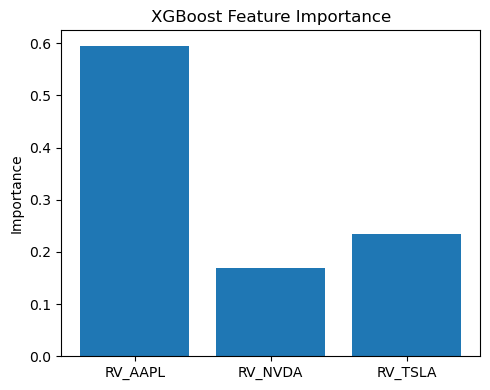

In [73]:
# ============================================================
# 6. Feature importance
# ============================================================

importances = xgb_model.feature_importances_

for col, imp in zip(feature_cols, importances):
    print(f"Feature importance - {col}: {imp:.4f}")

plt.figure(figsize=(5,4))
plt.bar(feature_cols, importances)
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [87]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Features
X = data[["RV_AAPL", "RV_NVDA", "RV_TSLA"]].values
y = data["RV_SPX"].values

# Train/test split (time-based)
train_size = int(len(data) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# LASSO model
lasso = Lasso(alpha=0.001)   # you can tune alpha
lasso.fit(X_train, y_train)

# Predictions
y_pred = lasso.predict(X_test)

# Metrics
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred))
mae_lasso = mean_absolute_error(y_test, y_pred)
r2_lasso  = r2_score(y_test, y_pred)

print("LASSO RMSE:", round(rmse_lasso,3))
print("LASSO MAE :", round(mae_lasso,3))
print("LASSO R²  :", round(r2_lasso,3))

print("Coefficients:", lasso.coef_.round(3),)


LASSO RMSE: 0.031
LASSO MAE : 0.025
LASSO R²  : 0.724
Coefficients: [0.387 0.203 0.07 ]


In [88]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Features and target
X = data[["RV_AAPL", "RV_NVDA", "RV_TSLA"]].values
y = data["RV_SPX"].values

# Time-based train/test split
train_size = int(len(data) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", round(rmse_rf,3))
print("Random Forest MAE :", round(mae_rf,3))
print("Random Forest R²  :", round(r2_rf,3))


Random Forest RMSE: 0.049
Random Forest MAE : 0.037
Random Forest R²  : 0.326



================ MODEL COMPARISON ================
                     Model   RMSE    MAE     R²
1                    LASSO  0.031  0.025  0.724
0  OLS (Linear Regression)  0.032  0.025  0.710
2                  XGBoost  0.042  0.033  0.503
3            Random Forest  0.049  0.037  0.326


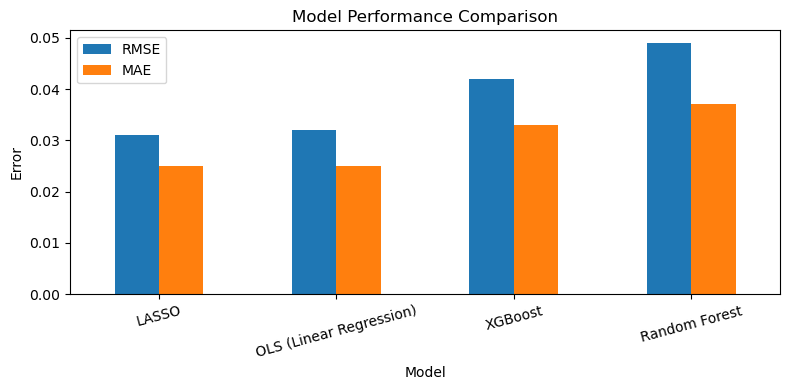

In [89]:
# ============================================================
# Build comparison table
# ============================================================

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values("RMSE")  # smaller RMSE = better
comparison_df = comparison_df.round(3)

print("\n================ MODEL COMPARISON ================")
print(comparison_df)

# Optional: pretty display
# from IPython.display import display
# display(comparison_df)

# Optional: bar plot of errors
import matplotlib.pyplot as plt

comparison_df.set_index("Model")[["RMSE", "MAE"]].plot(kind="bar", figsize=(8, 4))
plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()




OLS provides a strong and reliable benchmark, showing that a linear structure captures most volatility transmission effects. Among the selection models, LASSO delivers the best performance with the lowest RMSE and MAE, indicating that regularization improves predictive accuracy beyond the benchmark. In contrast, XGBoost and Random Forest exhibit higher errors and weaker generalization, suggesting they are less suitable for this financial time-series context. Overall, while OLS is a solid baseline, LASSO is the most effective model for comparison.